# Exploration Notebook
Understand the data before building detection pipelines.

## 1. Setup

In [1]:
%pip install opencv-python --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/videos")
META_PATH = DATA_DIR / "metadata.csv"


## 2. Metadata Overview

In [3]:
df = pd.read_csv(META_PATH)
print(f"Pitches: {len(df)}")
print(f"Columns: {len(df.columns)}")
df[["pitch_type", "pitch_name", "player_name", "release_speed",
    "release_pos_x", "release_pos_z", "release_extension", "filename"]].head(10)


Pitches: 50
Columns: 121


,pitch_type,pitch_name,player_name,release_speed,release_pos_x,release_pos_z,release_extension,filename
0,SI,Sinker,"Lord, Brad",94.4,-2.40,5.28,5.5,776440_be6c4fa5_SI.mp4
1,FF,4-Seam Fastball,"Cameron, Noah",92.9,1.15,6.21,6.4,776463_a6795e29_FF.mp4
2,SL,Slider,"Soto, Gregory",86.5,2.12,5.54,6.7,776148_7f042c3a_SL.mp4
3,ST,Sweeper,"Raley, Brooks",81.8,3.14,5.30,6.5,776259_7162d643_ST.mp4
4,SI,Sinker,"Ashby, Aaron",97.2,0.20,6.53,5.5,776274_2662a7aa_SI.mp4
5,FF,4-Seam Fastball,"Brown, Hunter",97.2,-1.95,6.22,6.8,776262_97c2b3d0_FF.mp4
6,SL,Slider,"Mikolas, Miles",86.8,-1.96,6.74,6.0,776400_56e30c6e_SL.mp4
7,ST,Sweeper,"Ober, Bailey",78.4,-1.54,5.87,7.1,776324_ff20a37e_ST.mp4
8,FF,4-Seam Fastball,"Herget, Kevin",91.3,-1.96,5.91,5.6,776490_eaeffe7a_FF.mp4
9,FF,4-Seam Fastball,"Alexander, Tyler",89.9,2.51,5.50,6.4,776306_1ac078b1_FF.mp4


In [4]:
# Pitch type distribution
print("Pitch type counts:")
print(df["pitch_type"].value_counts())
print()
print("Release point stats (Statcast ground truth):")
print(df[["release_pos_x", "release_pos_z", "release_extension"]].describe().round(3))


Pitch type counts:
pitch_type
FF    14
SI    11
SL     7
ST     6
CU     4
CH     3
KC     2
FC     2
FS     1
Name: count, dtype: int64

Release point stats (Statcast ground truth):
       release_pos_x  release_pos_z  release_extension
count         50.000         50.000             50.000
mean          -0.997          5.774              6.380
std            1.859          0.528              0.501
min           -3.330          4.790              4.900
25%           -2.178          5.365              6.000
50%           -1.720          5.725              6.450
75%           -0.495          6.210              6.800
max            4.060          6.800              7.300


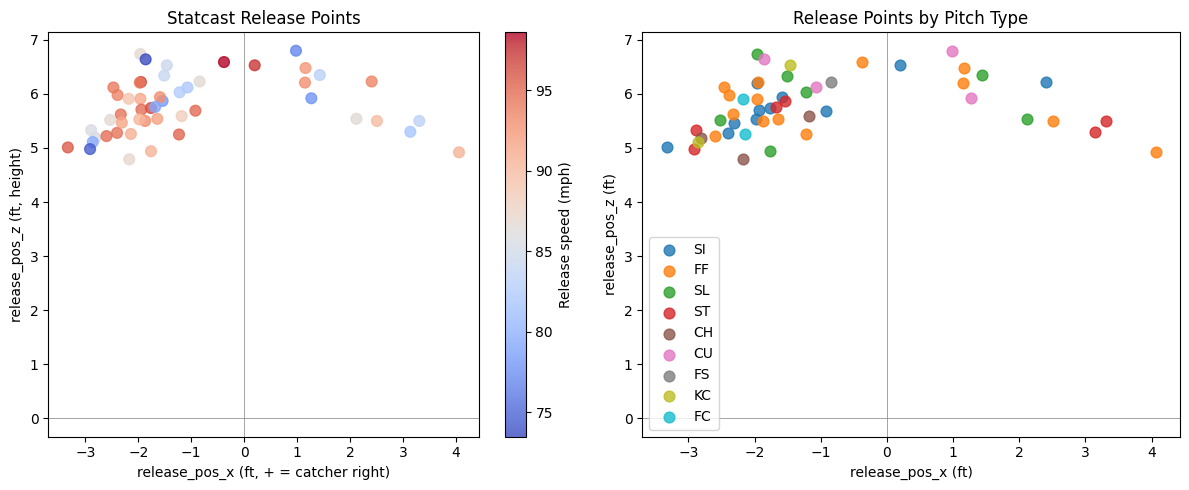

In [5]:
# Visualize release point spread from Statcast
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter = axes[0].scatter(
    df["release_pos_x"], df["release_pos_z"],
    c=df["release_speed"], cmap="coolwarm", s=60, alpha=0.8
)
plt.colorbar(scatter, ax=axes[0], label="Release speed (mph)")
axes[0].set_xlabel("release_pos_x (ft, + = catcher right)")
axes[0].set_ylabel("release_pos_z (ft, height)")
axes[0].set_title("Statcast Release Points")
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].axvline(0, color="gray", linewidth=0.5)

# Color by pitch type
pitch_types = df["pitch_type"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(pitch_types)))
for pt, color in zip(pitch_types, colors):
    mask = df["pitch_type"] == pt
    axes[1].scatter(df[mask]["release_pos_x"], df[mask]["release_pos_z"],
                    label=pt, color=color, s=60, alpha=0.8)
axes[1].legend()
axes[1].set_xlabel("release_pos_x (ft)")
axes[1].set_ylabel("release_pos_z (ft)")
axes[1].set_title("Release Points by Pitch Type")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()


## 3. Video Properties

In [6]:
# Summarize all videos
rows = []
for mp4 in sorted(DATA_DIR.glob("*.mp4")):
    cap = cv2.VideoCapture(str(mp4))
    rows.append({
        "file": mp4.name,
        "fps": round(cap.get(cv2.CAP_PROP_FPS), 1),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "frames": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "duration_s": round(cap.get(cv2.CAP_PROP_FRAME_COUNT) / max(cap.get(cv2.CAP_PROP_FPS), 1), 2),
    })
    cap.release()

vid_df = pd.DataFrame(rows)
print(vid_df.to_string(index=False))
print()
print("FPS:", vid_df["fps"].unique())
print("Resolution:", vid_df[["width","height"]].drop_duplicates().values)
print(f"Avg duration: {vid_df['duration_s'].mean():.1f}s  |  Avg frames: {vid_df['frames'].mean():.0f}")


                  file  fps  width  height  frames  duration_s
776148_5399cd45_SL.mp4 59.4   1280     720     389        6.55
776148_7f042c3a_SL.mp4 59.8   1280     720     810       13.56
776172_6f6ed226_CU.mp4 59.7   1280     720     391        6.55
776174_14e37386_FF.mp4 59.4   1280     720     393        6.61
776204_3556e48d_KC.mp4 59.7   1280     720     662       11.09
776208_bed07cfa_ST.mp4 59.5   1280     720     394        6.62
776213_c2ad708a_ST.mp4 59.6   1280     720     464        7.79
776213_dba945a9_CH.mp4 59.5   1280     720     410        6.89
776214_e574fa80_FC.mp4 59.6   1280     720     419        7.03
776216_46c514fd_CH.mp4 59.5   1280     720     433        7.28
776244_992f73c1_SI.mp4 59.7   1280     720     437        7.32
776251_9aba59f6_CU.mp4 59.6   1280     720     440        7.38
776259_7162d643_ST.mp4 59.7   1280     720     554        9.28
776262_97c2b3d0_FF.mp4 59.7   1280     720     659       11.03
776274_2662a7aa_SI.mp4 59.6   1280     720     462     

## 4. Sample Frames from One Video

Sampling from: 776148_5399cd45_SL.mp4


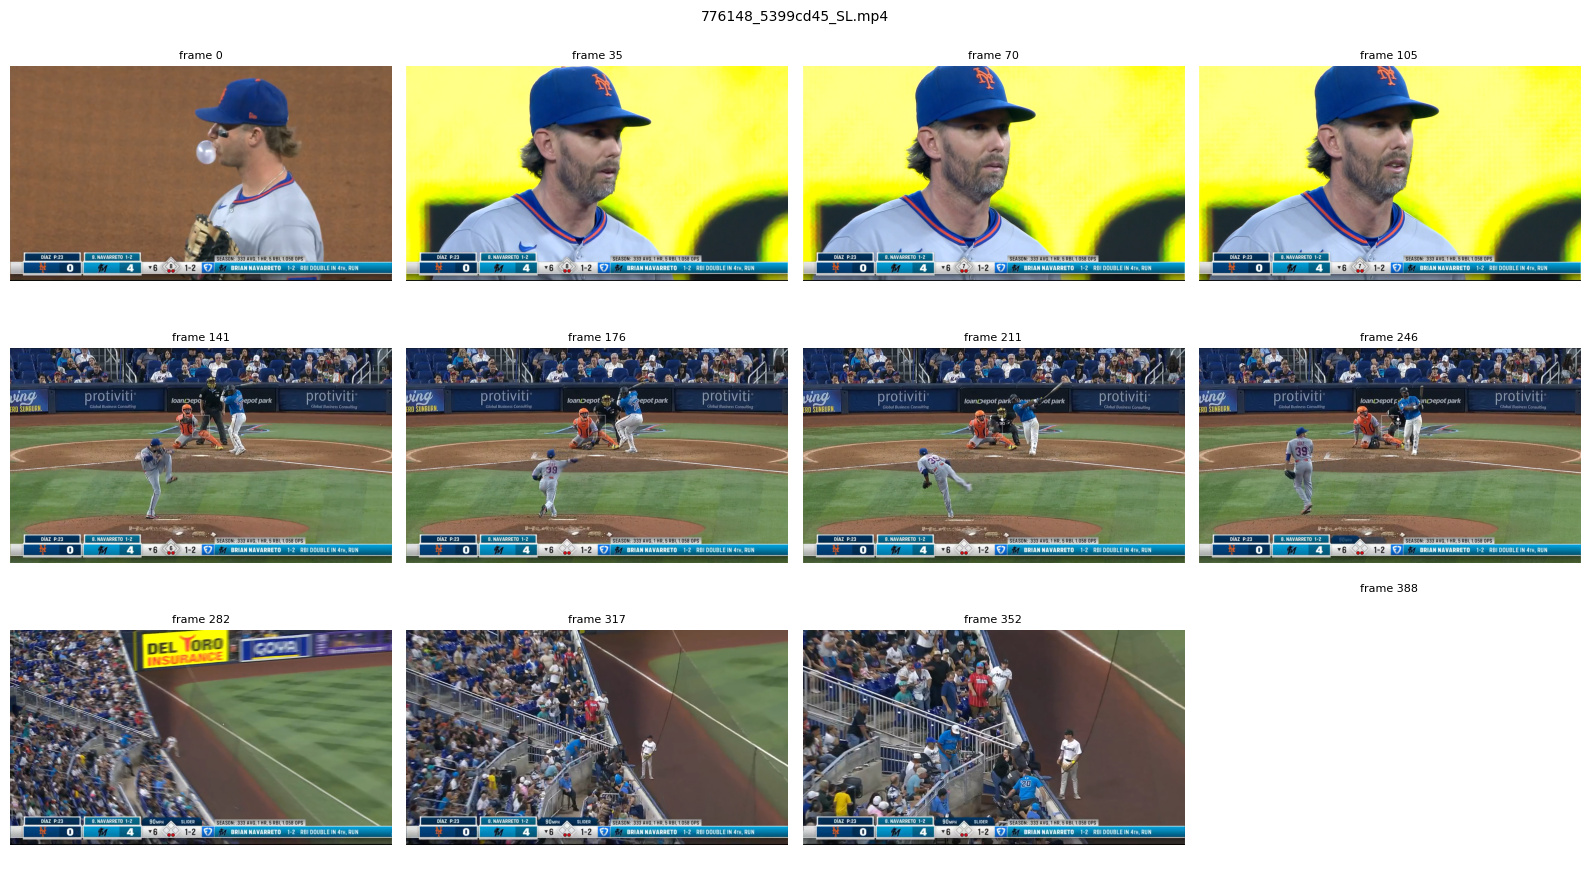

In [7]:
SAMPLE_VIDEO = sorted(DATA_DIR.glob("*.mp4"))[0]
print(f"Sampling from: {SAMPLE_VIDEO.name}")

cap = cv2.VideoCapture(str(SAMPLE_VIDEO))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Evenly spaced frames across the video
sample_indices = np.linspace(0, total_frames - 1, 12, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, idx in zip(axes.flat, sample_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {idx}", fontsize=8)
    ax.axis("off")
cap.release()
plt.suptitle(SAMPLE_VIDEO.name, fontsize=10)
plt.tight_layout()
plt.show()


## 5. Background Subtraction — Ball Detection Attempt
MOG2 subtracts the static background (mound, grass, stands) and returns moving foreground blobs. The baseball should appear as a small bright blob.

In [19]:
# SAMPLE_VIDEO = DATA_DIR / "776148_5399cd45_SL.mp4"
SAMPLE_VIDEO = DATA_DIR / "776425_62e20169_FF.mp4" 

cap = cv2.VideoCapture(str(SAMPLE_VIDEO))
fgbg = cv2.createBackgroundSubtractorMOG2(history=30, varThreshold=50, detectShadows=False)

# Warm up the background model on the first 30 frames
for _ in range(80):
    ret, frame = cap.read()
    if ret:
        fgbg.apply(frame)

# Collect foreground masks for next 60 frames
masks, frames_rgb = [], []
for _ in range(60):
    ret, frame = cap.read()
    if not ret:
        break
    mask = fgbg.apply(frame)
    # Morphological cleanup: remove noise, fill small gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    masks.append(mask)
    frames_rgb.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

print(f"Collected {len(masks)} frames")


Collected 60 frames


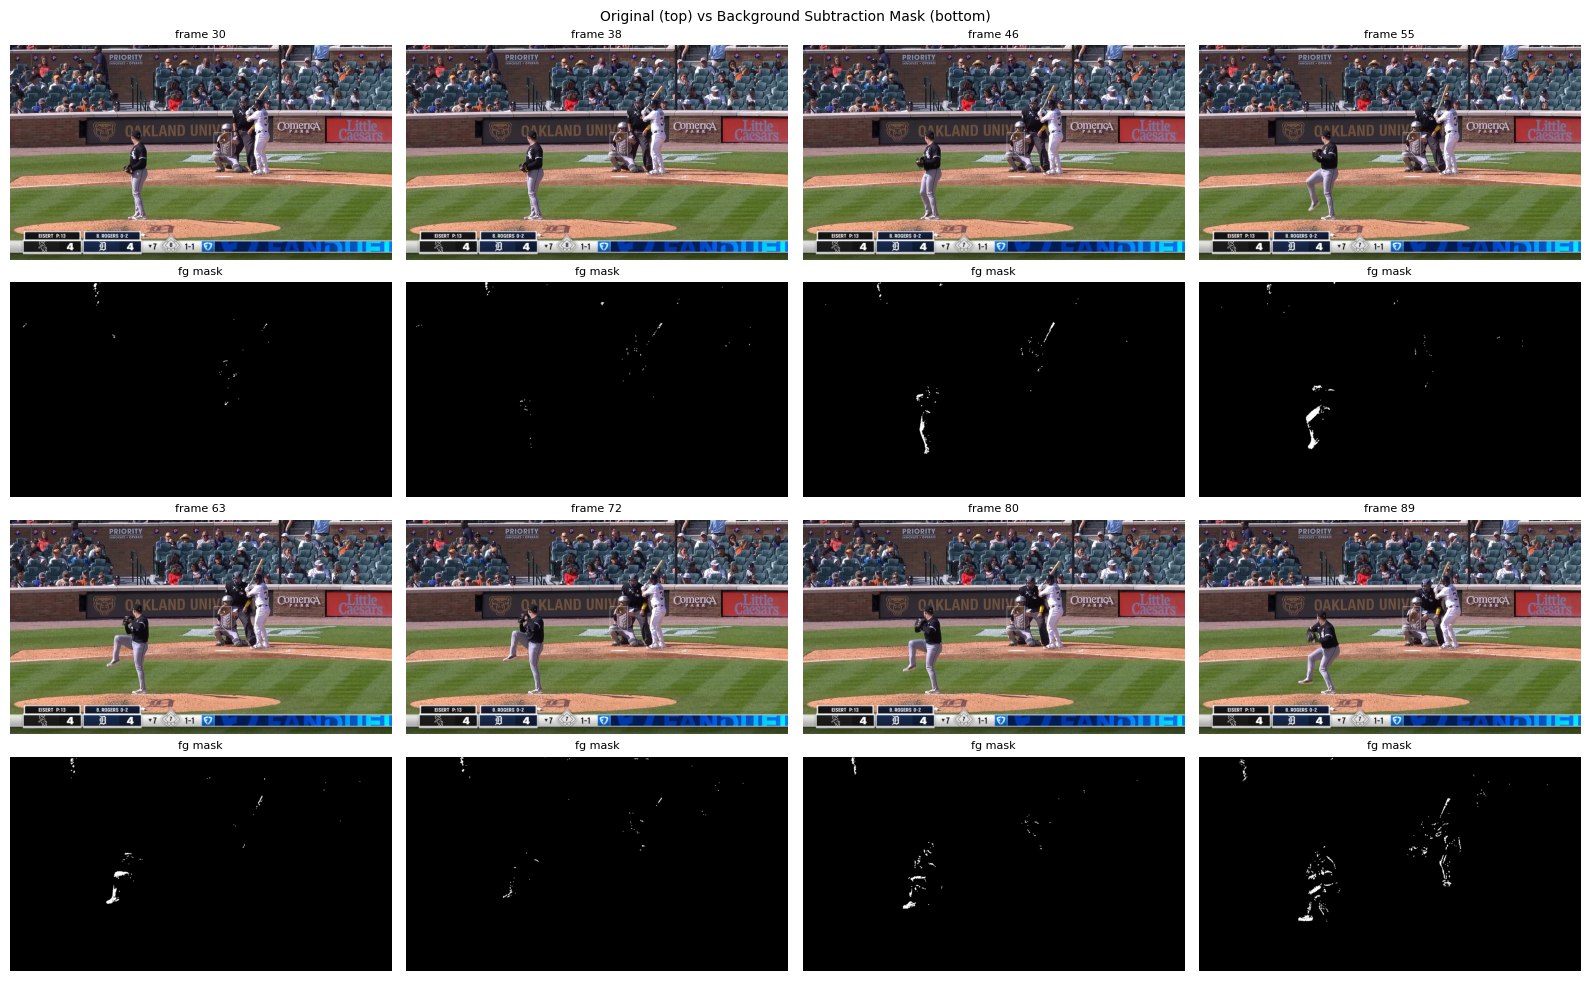

In [20]:
# Show a few frames with their foreground masks side-by-side
fig, axes = plt.subplots(4, 4, figsize=(16, 10))
sample_idx = np.linspace(0, len(masks)-1, 8, dtype=int)
for i, idx in enumerate(sample_idx):
    axes[i//4*2, i%4].imshow(frames_rgb[idx])
    axes[i//4*2, i%4].set_title(f"frame {30+idx}", fontsize=8)
    axes[i//4*2, i%4].axis("off")
    axes[i//4*2+1, i%4].imshow(masks[idx], cmap="gray")
    axes[i//4*2+1, i%4].set_title("fg mask", fontsize=8)
    axes[i//4*2+1, i%4].axis("off")
plt.suptitle("Original (top) vs Background Subtraction Mask (bottom)", fontsize=10)
plt.tight_layout()
plt.show()


In [21]:
# Baseball at 1280x720 is ~8-15px diameter => area ~50-175px²
# min_area=50 filters out pixel-noise; max_area=300 filters out large blobs (players, logos)
# circularity >= 0.55 keeps roughly circular shapes only

def find_ball_candidates(mask, min_area=50, max_area=300, min_circularity=0.55):
    """Return centroids of contours that could be a baseball."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if not (min_area < area < max_area):
            continue
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
        circularity = 4 * np.pi * area / (perimeter ** 2)
        if circularity < min_circularity:
            continue
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        candidates.append({"x": cx, "y": cy, "area": round(area, 1), "circularity": round(circularity, 2)})
    return candidates

detections = [find_ball_candidates(m) for m in masks]
detected_count = sum(1 for d in detections if d)
print(f"Frames with at least one ball candidate: {detected_count}/{len(masks)}")
print()
# Show the distribution of candidate counts per frame
from collections import Counter
counts = Counter(len(d) for d in detections)
for n, freq in sorted(counts.items()):
    print(f"  {n} candidate(s): {freq} frames")


Frames with at least one ball candidate: 5/60

  0 candidate(s): 55 frames
  1 candidate(s): 5 frames


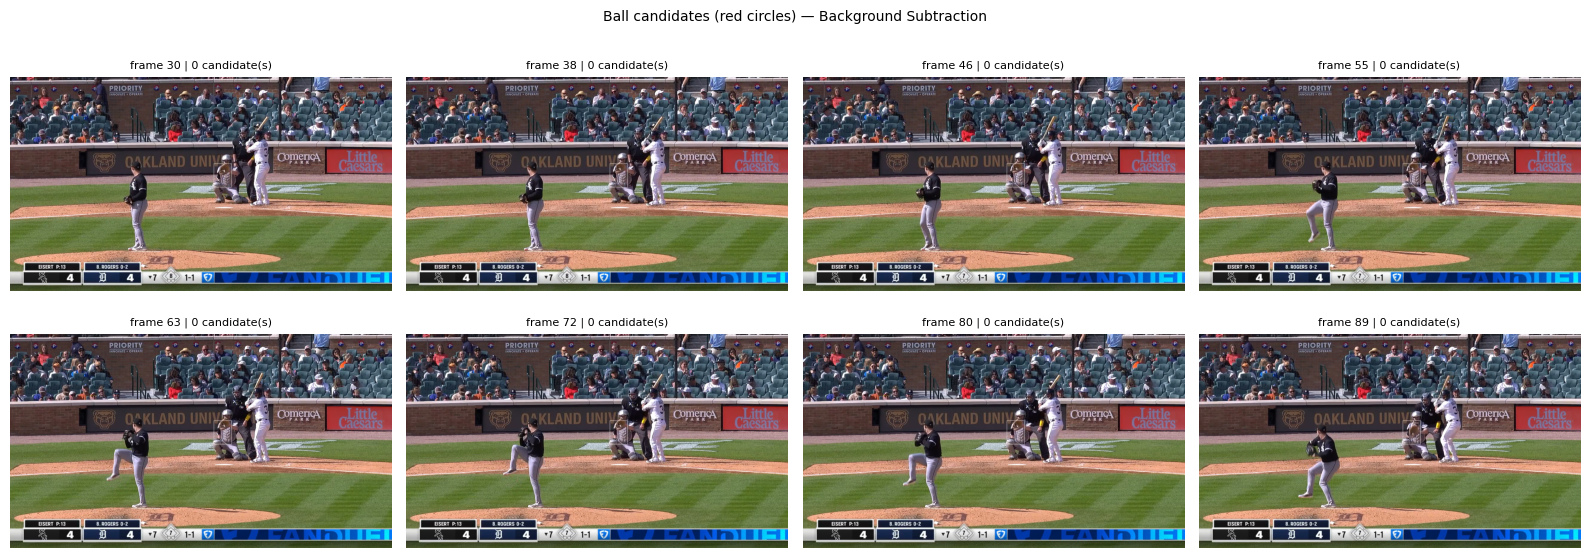

In [22]:
# Overlay detections on frames
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, idx in zip(axes.flat, np.linspace(0, len(masks)-1, 8, dtype=int)):
    vis = frames_rgb[idx].copy()
    for det in detections[idx]:
        cv2.circle(vis, (det["x"], det["y"]), 12, (255, 0, 0), 2)
        cv2.circle(vis, (det["x"], det["y"]), 2, (255, 0, 0), -1)
    ax.imshow(vis)
    ax.set_title(f"frame {30+idx} | {len(detections[idx])} candidate(s)", fontsize=8)
    ax.axis("off")
plt.suptitle("Ball candidates (red circles) — Background Subtraction", fontsize=10)
plt.tight_layout()
plt.show()


## 6. Do Detections Form a Trajectory?

Frames with detection: 5
 Frame      x      y    area   circ
    33    280      6    66.0   0.74
    41    539    669    85.5   0.58
    56    410    457    52.0   0.61
    87    148     20    77.5   0.56
    88    414    387    89.5   0.56


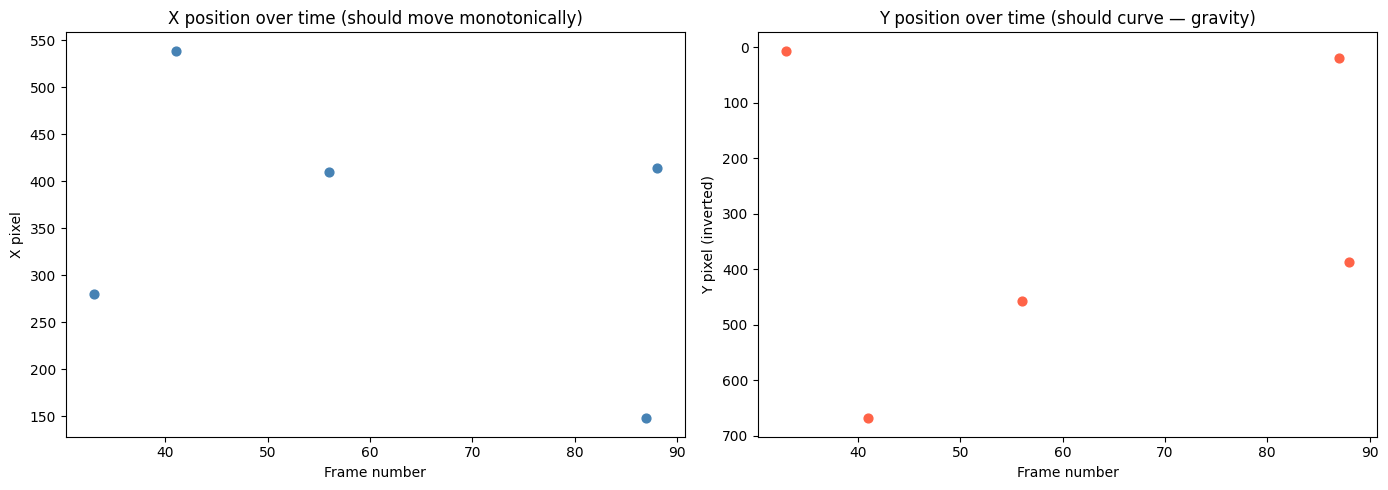

In [23]:
# Pick best candidate per frame (highest circularity), print table
best_per_frame = []
for frame_idx, dets in enumerate(detections):
    if dets:
        best = max(dets, key=lambda d: d["circularity"])
        best_per_frame.append((30 + frame_idx, best["x"], best["y"], best["area"], best["circularity"]))

print(f"Frames with detection: {len(best_per_frame)}")
print(f"{'Frame':>6}  {'x':>5}  {'y':>5}  {'area':>6}  {'circ':>5}")
for row in best_per_frame:
    print(f"{row[0]:>6}  {row[1]:>5}  {row[2]:>5}  {row[3]:>6.1f}  {row[4]:>5.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if best_per_frame:
    frames_t, xs, ys = zip(*[(r[0], r[1], r[2]) for r in best_per_frame])
    axes[0].scatter(frames_t, xs, c="steelblue", s=40)
    axes[0].set_xlabel("Frame number"); axes[0].set_ylabel("X pixel")
    axes[0].set_title("X position over time (should move monotonically)")
    axes[1].scatter(frames_t, ys, c="tomato", s=40)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Frame number"); axes[1].set_ylabel("Y pixel (inverted)")
    axes[1].set_title("Y position over time (should curve — gravity)")
plt.tight_layout()
plt.show()


## 7. Diagnose Missed Frames
Find frames where blobs existed but were filtered out — helps tune thresholds.

Missed frames with filtered-out blobs: 55


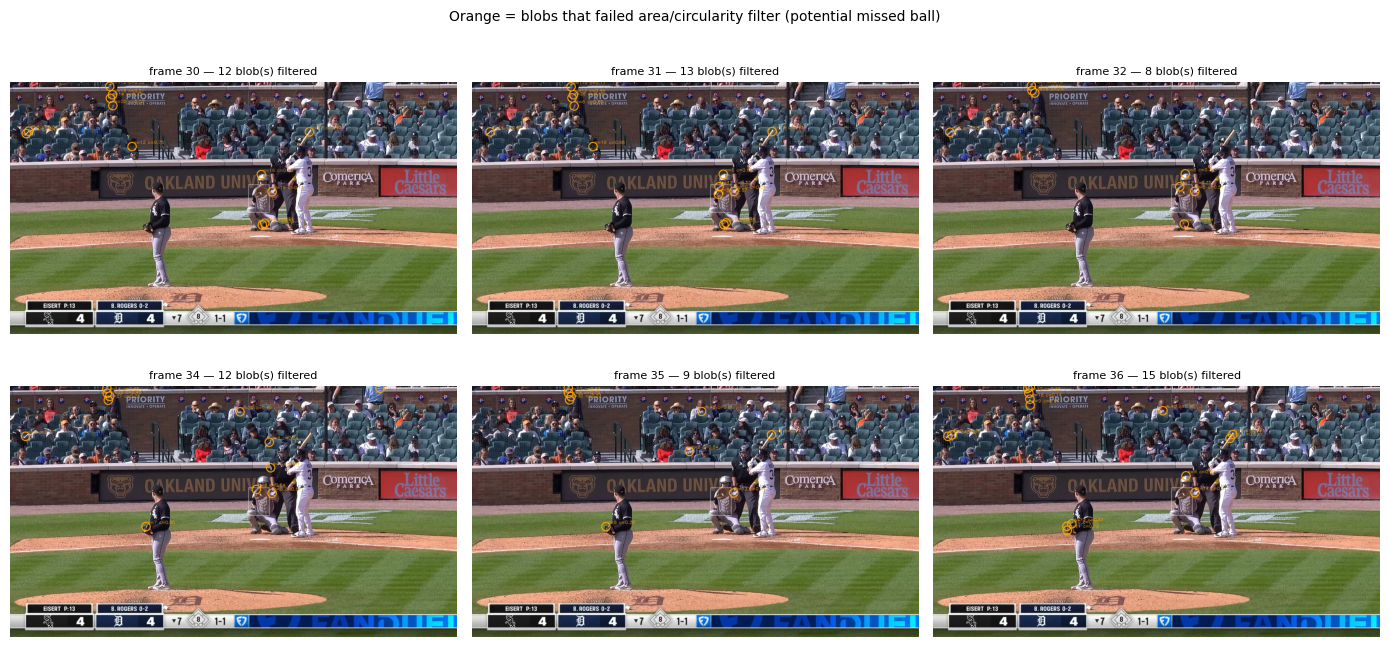

In [24]:
def get_all_blobs(mask, min_area=5):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        perimeter = cv2.arcLength(cnt, True)
        circ = (4 * np.pi * area / perimeter ** 2) if perimeter > 0 else 0
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        blobs.append({"x": int(M["m10"]/M["m00"]), "y": int(M["m01"]/M["m00"]),
                      "area": round(area, 1), "circularity": round(circ, 2)})
    return blobs

missed_with_blobs = [
    (i, get_all_blobs(masks[i]))
    for i in range(len(masks))
    if not detections[i] and get_all_blobs(masks[i])
]
print(f"Missed frames with filtered-out blobs: {len(missed_with_blobs)}")

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (idx, blobs) in zip(axes.flat, missed_with_blobs[:6]):
    vis = frames_rgb[idx].copy()
    for b in blobs:
        cv2.circle(vis, (b["x"], b["y"]), 12, (255, 165, 0), 2)
        cv2.putText(vis, f"a={b['area']:.0f} c={b['circularity']:.2f}",
                    (b["x"]+5, b["y"]-8), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,165,0), 1)
    ax.imshow(vis)
    ax.set_title(f"frame {30+idx} — {len(blobs)} blob(s) filtered", fontsize=8)
    ax.axis("off")
plt.suptitle("Orange = blobs that failed area/circularity filter (potential missed ball)", fontsize=10)
plt.tight_layout()
plt.show()


## 8. Temporal Filtering
A real ball cannot teleport. Filter detections by requiring each position to be within a max distance of the previous detection.

Before filtering: 5 detections
After temporal filter: 1 detections


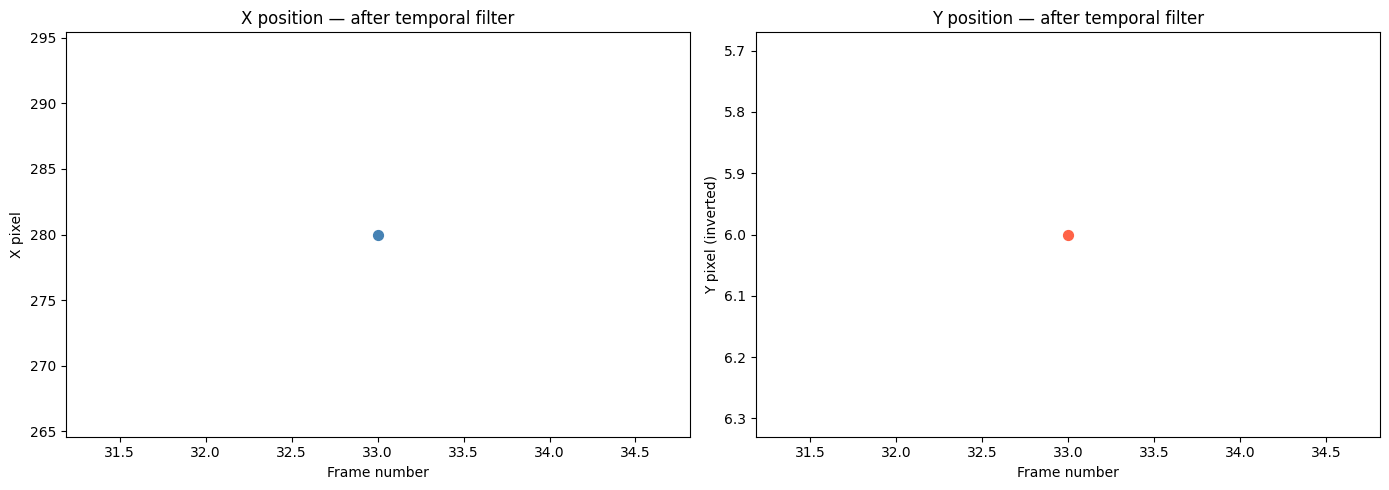

In [25]:
MAX_JUMP_PX = 80   # max pixels a ball can move between consecutive frames at ~59fps

def temporal_filter(detections, max_jump=MAX_JUMP_PX):
    """
    Walk through frames in order. Start a track when we see a detection.
    Only accept the next detection if it's within max_jump pixels of the last accepted one.
    Returns list of (frame_idx, x, y, area, circularity) for the filtered track.
    """
    track = []
    for frame_idx, dets in enumerate(detections):
        if not dets:
            continue
        if not track:
            # Start track with best candidate (highest circularity)
            best = max(dets, key=lambda d: d["circularity"])
            track.append((30 + frame_idx, best["x"], best["y"], best["area"], best["circularity"]))
            continue
        # Find candidate closest to last accepted position
        last_x, last_y = track[-1][1], track[-1][2]
        closest = min(dets, key=lambda d: (d["x"]-last_x)**2 + (d["y"]-last_y)**2)
        dist = ((closest["x"]-last_x)**2 + (closest["y"]-last_y)**2) ** 0.5
        if dist <= max_jump:
            track.append((30 + frame_idx, closest["x"], closest["y"], closest["area"], closest["circularity"]))
        # else: skip this frame — gap in track

    return track

filtered_track = temporal_filter(detections)
print(f"Before filtering: {sum(1 for d in detections if d)} detections")
print(f"After temporal filter: {len(filtered_track)} detections")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if filtered_track:
    frames_t, xs, ys = zip(*[(r[0], r[1], r[2]) for r in filtered_track])
    axes[0].scatter(frames_t, xs, c="steelblue", s=50)
    axes[0].set_xlabel("Frame number"); axes[0].set_ylabel("X pixel")
    axes[0].set_title("X position — after temporal filter")

    axes[1].scatter(frames_t, ys, c="tomato", s=50)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Frame number"); axes[1].set_ylabel("Y pixel (inverted)")
    axes[1].set_title("Y position — after temporal filter")

plt.tight_layout()
plt.show()


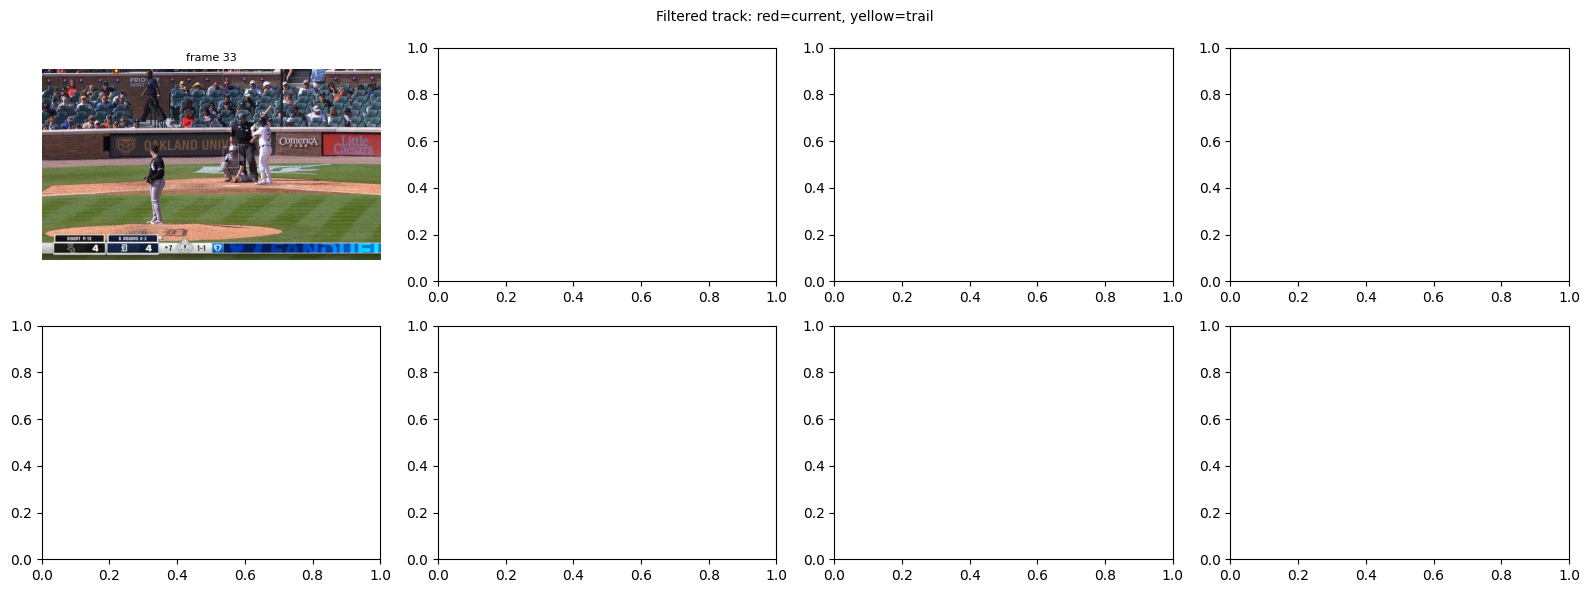

In [26]:
# Overlay the filtered track on the video frames as a trail
cap = cv2.VideoCapture(str(SAMPLE_VIDEO))
track_set = {r[0]: (r[1], r[2]) for r in filtered_track}

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
sample_frames = sorted(track_set.keys())[:8] if len(track_set) >= 8 else sorted(track_set.keys())

for ax, fnum in zip(axes.flat, sample_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fnum)
    ret, frame = cap.read()
    if not ret:
        continue
    vis = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).copy()
    # Draw trail: all prior track points
    for prev_fnum, (px, py) in track_set.items():
        if prev_fnum <= fnum:
            cv2.circle(vis, (px, py), 5, (255, 255, 0), -1)
    # Draw current detection larger
    cx, cy = track_set[fnum]
    cv2.circle(vis, (cx, cy), 12, (255, 0, 0), 2)
    ax.imshow(vis)
    ax.set_title(f"frame {fnum}", fontsize=8)
    ax.axis("off")
cap.release()
plt.suptitle("Filtered track: red=current, yellow=trail", fontsize=10)
plt.tight_layout()
plt.show()


## 9. Find the Pitch View Automatically
Detect the scene cut from close-up/replay to center-field pitch view using frame difference magnitude.

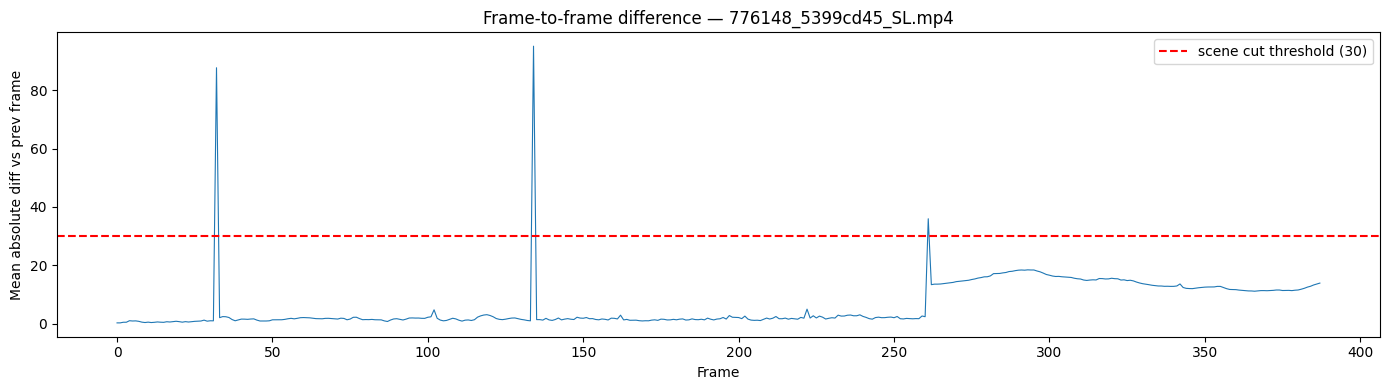

Total frames: 389
Detected pitch segment: frames 262 → 389


In [27]:
def find_pitch_segment(video_path, diff_threshold=30.0, min_stable_frames=20):
    """
    Scan the video and find where the scene stabilizes into a pitch view.
    Large frame-to-frame diff = scene cut or fast motion.
    We want the last major scene cut, after which the background is stable.
    Returns: (start_frame, end_frame) of the best pitch segment.
    """
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    diffs = []
    prev_gray = None
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if prev_gray is not None:
            diff = np.abs(gray.astype(float) - prev_gray.astype(float)).mean()
            diffs.append((i, diff))
        prev_gray = gray
    cap.release()

    # Find the last large scene cut (diff spike)
    scene_cuts = [i for i, d in diffs if d > diff_threshold]
    
    if not scene_cuts:
        return 0, total
    
    last_cut = scene_cuts[-1]
    return last_cut, total

# Test on our sample video
SAMPLE_VIDEO = DATA_DIR / "776148_5399cd45_SL.mp4"
cap = cv2.VideoCapture(str(SAMPLE_VIDEO))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

# Plot frame-to-frame difference to visualize scene cuts
cap = cv2.VideoCapture(str(SAMPLE_VIDEO))
diffs = []
prev_gray = None
for i in range(total_frames):
    ret, frame = cap.read()
    if not ret: break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    if prev_gray is not None:
        diffs.append(np.abs(gray.astype(float) - prev_gray.astype(float)).mean())
    prev_gray = gray
cap.release()

plt.figure(figsize=(14, 4))
plt.plot(diffs, linewidth=0.8)
plt.axhline(30, color="red", linestyle="--", label="scene cut threshold (30)")
plt.xlabel("Frame"); plt.ylabel("Mean absolute diff vs prev frame")
plt.title(f"Frame-to-frame difference — {SAMPLE_VIDEO.name}")
plt.legend()
plt.tight_layout()
plt.show()

pitch_start, pitch_end = find_pitch_segment(SAMPLE_VIDEO)
print(f"Total frames: {total_frames}")
print(f"Detected pitch segment: frames {pitch_start} → {pitch_end}")


In [28]:
# Re-run ball detection only on the pitch segment
pitch_start, pitch_end = find_pitch_segment(SAMPLE_VIDEO)
warmup = 15  # warm up MOG2 for 15 frames after scene cut before detecting

cap = cv2.VideoCapture(str(SAMPLE_VIDEO))
cap.set(cv2.CAP_PROP_POS_FRAMES, pitch_start)

fgbg = cv2.createBackgroundSubtractorMOG2(history=20, varThreshold=40, detectShadows=False)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

masks2, frames_rgb2 = [], []

for i in range(pitch_end - pitch_start):
    ret, frame = cap.read()
    if not ret: break
    mask = fgbg.apply(frame)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    if i >= warmup:
        masks2.append(mask)
        frames_rgb2.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

detections2 = [find_ball_candidates(m) for m in masks2]
detected_count = sum(1 for d in detections2 if d)
print(f"Pitch segment: {len(masks2)} frames analyzed")
print(f"Frames with ball candidate: {detected_count}")

from collections import Counter
counts = Counter(len(d) for d in detections2)
for n, freq in sorted(counts.items()):
    print(f"  {n} candidate(s): {freq} frames")


Pitch segment: 112 frames analyzed
Frames with ball candidate: 102
  0 candidate(s): 10 frames
  1 candidate(s): 24 frames
  2 candidate(s): 14 frames
  3 candidate(s): 13 frames
  4 candidate(s): 4 frames
  5 candidate(s): 7 frames
  6 candidate(s): 6 frames
  7 candidate(s): 9 frames
  8 candidate(s): 3 frames
  9 candidate(s): 3 frames
  10 candidate(s): 2 frames
  11 candidate(s): 2 frames
  12 candidate(s): 4 frames
  13 candidate(s): 3 frames
  14 candidate(s): 2 frames
  15 candidate(s): 1 frames
  16 candidate(s): 3 frames
  17 candidate(s): 1 frames
  21 candidate(s): 1 frames


After temporal filter: 16 detections


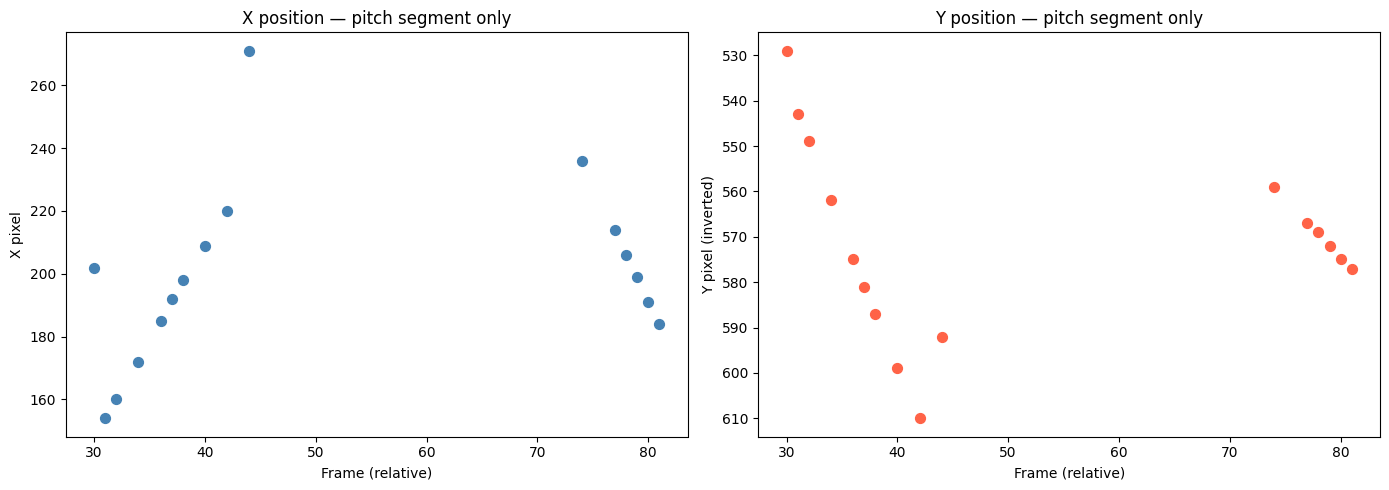

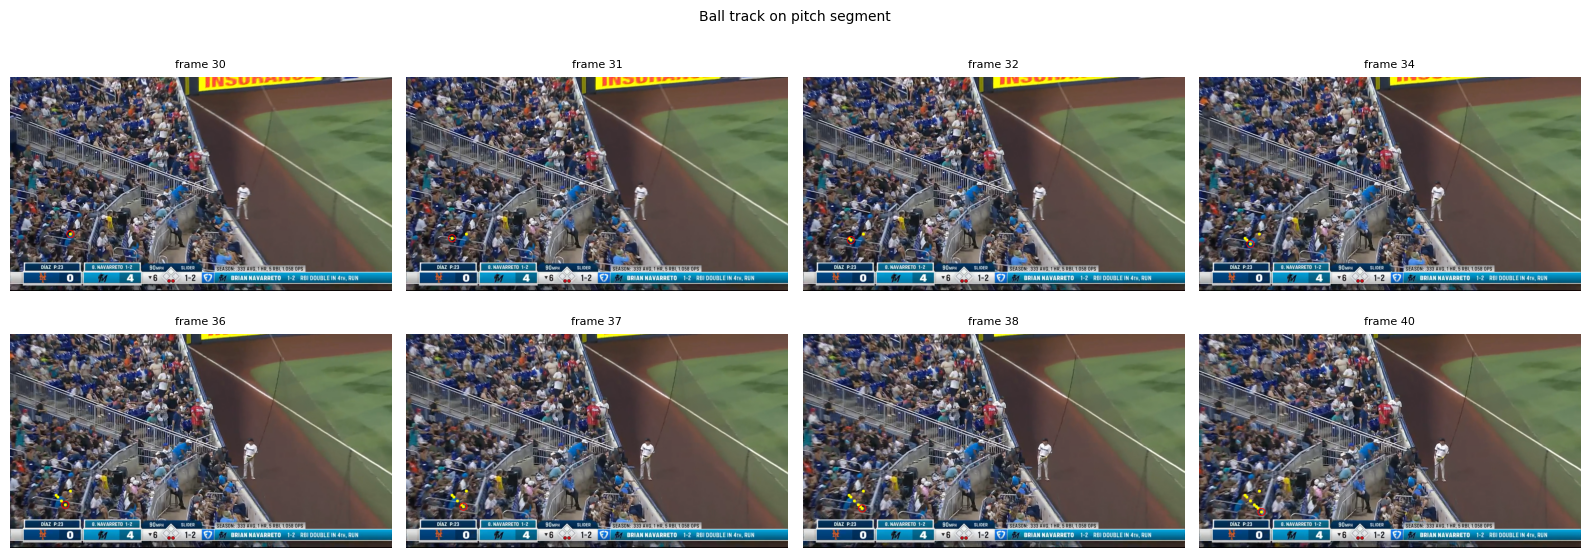

In [29]:
# Apply temporal filter and plot trajectory on pitch segment
filtered2 = temporal_filter(detections2, max_jump=60)
print(f"After temporal filter: {len(filtered2)} detections")

if len(filtered2) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    frames_t2, xs2, ys2 = zip(*[(r[0], r[1], r[2]) for r in filtered2])
    axes[0].scatter(frames_t2, xs2, c="steelblue", s=50)
    axes[0].set_xlabel("Frame (relative)"); axes[0].set_ylabel("X pixel")
    axes[0].set_title("X position — pitch segment only")
    axes[1].scatter(frames_t2, ys2, c="tomato", s=50)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Frame (relative)"); axes[1].set_ylabel("Y pixel (inverted)")
    axes[1].set_title("Y position — pitch segment only")
    plt.tight_layout()
    plt.show()

    # Show overlay on actual frames
    track_map = {r[0]: (r[1], r[2]) for r in filtered2}
    sample_keys = sorted(track_map.keys())[:8]
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for ax, fnum in zip(axes.flat, sample_keys):
        vis = frames_rgb2[fnum].copy()
        for pf, (px, py) in track_map.items():
            if pf <= fnum:
                cv2.circle(vis, (px, py), 5, (255, 255, 0), -1)
        cx, cy = track_map[fnum]
        cv2.circle(vis, (cx, cy), 12, (255, 0, 0), 2)
        ax.imshow(vis); ax.set_title(f"frame {fnum}", fontsize=8); ax.axis("off")
    plt.suptitle("Ball track on pitch segment", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Too few detections — check the frame diff plot and adjust threshold")
